In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import os

from color_mapping import clean_color_column
from country_mapping import clean_country_column

# ============================================================
# 1. Load data
# ============================================================

file_path = r"C:\Users\nikin\Desktop\IphonesFinal.xlsx"
df = pd.read_excel(file_path)

print("Original dataset shape:", df.shape)
print("\nOriginal columns:")
print(df.columns)


# ============================================================
# 2. Cleaning functions
# ============================================================

def clean_price(value):
    if pd.isna(value):
        return np.nan
    
    value = (
        str(value)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    
    if value in ["", "N/A", "nan", "None"]:
        return np.nan
    
    return pd.to_numeric(value, errors="coerce")


def clean_seller_rating(value):
    if pd.isna(value):
        return np.nan
    
    value_str = str(value).strip()
    
    if value_str == "" or value_str.upper() == "N/A":
        return np.nan
    
    has_percent = "%" in value_str
    
    value_str = (
        value_str
        .replace("%", "")
        .replace(",", ".")
        .strip()
    )
    
    rating = pd.to_numeric(value_str, errors="coerce")
    
    if pd.isna(rating):
        return np.nan
    
    # If Excel stored 99% as 0.99 or 100% as 1
    if not has_percent and rating <= 1:
        rating = rating * 100
    
    return rating


def clean_seller_total_sales(value):
    if pd.isna(value):
        return np.nan
    
    value = (
        str(value)
        .replace(".", "")
        .replace(",", ".")
        .replace("+", "")
        .strip()
    )
    
    if value in ["", "N/A", "nan", "None"]:
        return np.nan
    
    return pd.to_numeric(value, errors="coerce")


def clean_text(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if value == "" or value.upper() == "N/A":
        return np.nan
    
    return value


# ============================================================
# 3. Create cleaned variables
# ============================================================

model_df = df.copy()

# Dependent variable
model_df["price"] = model_df["Preis"].apply(clean_price)

# Use your mapping files
model_df["Farbe_clean"] = clean_color_column(model_df["Farbe"])
model_df["country_group"] = clean_country_column(model_df["Herkunftsland"])

# Clean text variables
model_df["Zustand_clean"] = model_df["Zustand"].apply(clean_text).str.lower()
model_df["Seller_Type_clean"] = model_df["Seller Type"].apply(clean_text).str.lower()
model_df["Verkaufsart_clean"] = model_df["Verkaufsart"].apply(clean_text).str.lower()

# Clean numeric seller variables
model_df["seller_rating"] = model_df["Seller Rating"].apply(clean_seller_rating)
model_df["seller_total_sales"] = model_df["Zahl der verkauften Artikel"].apply(clean_seller_total_sales)

# Log seller sales because values range from 0 to millions
model_df["log_seller_total_sales"] = np.log1p(model_df["seller_total_sales"])


# ============================================================
# 4. Standardize categories
# ============================================================

# Zustand
model_df["Zustand_clean"] = model_df["Zustand_clean"].replace({
    "neu": "neu",
    "gebraucht": "gebraucht",
    "refurbished": "refurbished",
    "generalüberholt": "refurbished",
    "generaluberholt": "refurbished"
})

# Seller Type
model_df["Seller_Type_clean"] = model_df["Seller_Type_clean"].replace({
    "privat": "privat",
    "private": "privat",
    "gewerblich": "gewerblich",
    "commercial": "gewerblich"
})

# Verkaufsart
model_df["Verkaufsart_clean"] = model_df["Verkaufsart_clean"].replace({
    "sofortkauf": "sofortkauf",
    "auktion": "auktion",
    "sofortkauf + pr": "sofortkauf + pr"
})


# ============================================================
# 5. Handle suspicious seller ratings and missing ratings
# ============================================================

# Treat extremely low seller ratings as suspicious/outliers
# Keep this if you decided ratings below 80% should not influence the model
model_df.loc[model_df["seller_rating"] < 80, "seller_rating"] = np.nan

# Missing dummy: 1 = seller rating missing, 0 = seller rating available
model_df["seller_rating_missing"] = model_df["seller_rating"].isna().astype(int)

# Fill missing seller ratings with the mean so rows stay in the model
model_df["seller_rating_filled"] = model_df["seller_rating"].fillna(
    model_df["seller_rating"].mean()
)


# ============================================================
# 6. Check distributions before regression
# ============================================================

print("\nPrice summary:")
print(model_df["price"].describe())

print("\nSeller rating summary:")
print(model_df["seller_rating_filled"].describe())

print("\nMissing seller rating dummy:")
print(model_df["seller_rating_missing"].value_counts(dropna=False))

check_cols = [
    "Zustand_clean",
    "Farbe_clean",
    "Seller_Type_clean",
    "country_group",
    "Verkaufsart_clean"
]

for col in check_cols:
    print("\n" + "=" * 50)
    print(col)
    print(model_df[col].value_counts(dropna=False))


# ============================================================
# 7. Build regression dataframe
# ============================================================

regression_df = model_df[
    [
        "price",
        "Zustand_clean",
        "Farbe_clean",
        "Seller_Type_clean",
        "country_group",
        "Verkaufsart_clean",
        "seller_rating_filled",
        "seller_rating_missing",
        "log_seller_total_sales"
    ]
].copy()

print("\nBefore dropping missing values:", regression_df.shape)

print("\nMissing values before dropna:")
print(regression_df.isna().sum())

regression_df = regression_df.dropna()

print("\nAfter dropping missing values:", regression_df.shape)


# ============================================================
# 8. Main regression model
# ============================================================

formula = """
price ~ C(Zustand_clean, Treatment(reference="neu"))
      + C(Farbe_clean, Treatment(reference="schwarz"))
      + C(Seller_Type_clean, Treatment(reference="privat"))
      + C(country_group, Treatment(reference="deutschland"))
      + C(Verkaufsart_clean, Treatment(reference="sofortkauf"))
      + seller_rating_filled
      + seller_rating_missing
      + log_seller_total_sales
"""

main_model = smf.ols(formula=formula, data=regression_df).fit()

print("\n================ MAIN MODEL SUMMARY ================")
print(main_model.summary())


# ============================================================
# 9. Readable coefficient table
# ============================================================

results_table = pd.DataFrame({
    "Variable": main_model.params.index,
    "Coefficient": main_model.params.values,
    "P-value": main_model.pvalues.values
}).sort_values("P-value")

print("\n================ COEFFICIENT TABLE ================")
print(results_table)


# ============================================================
# 10. Model quality
# ============================================================

print("\n================ MODEL QUALITY ================")
print("Observations:", int(main_model.nobs))
print("R-squared:", round(main_model.rsquared, 4))
print("Adjusted R-squared:", round(main_model.rsquared_adj, 4))


# ============================================================
# 11. Optional: save cleaned regression data
# ============================================================

regression_df.to_excel("iphone17_main_model_cleaned_data.xlsx", index=False)
results_table.to_excel("iphone17_main_model_results.xlsx", index=False)

print("\nSaved files:")
print("iphone17_main_model_cleaned_data.xlsx")
print("iphone17_main_model_results.xlsx")

Original dataset shape: (491, 15)

Original columns:
Index(['Preis', 'Verkaufsart', 'Zustand', 'Farbe', 'Batteriezustand',
       'Batterie_Info_Vorhanden', 'Verkauft', 'Verfügbar', 'Herkunftsland',
       'Shop/Seller', 'Seller Rating', 'Seller Type',
       'Zahl der verkauften Artikel', 'log_verkauften', 'URL'],
      dtype='object')

Price summary:
count     491.000000
mean      829.978411
std       111.716256
min       505.000000
25%       755.725000
50%       800.000000
75%       892.490000
max      1399.570000
Name: price, dtype: float64

Seller rating summary:
count    491.000000
mean      99.411086
std        1.415414
min       86.700000
25%       99.411086
50%       99.900000
75%      100.000000
max      100.000000
Name: seller_rating_filled, dtype: float64

Missing seller rating dummy:
seller_rating_missing
0    451
1     40
Name: count, dtype: int64

Zustand_clean
Zustand_clean
neu            397
gebraucht       58
refurbished     36
Name: count, dtype: int64

Farbe_clean
F

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import patsy
import pandas as pd

y_vif, X_vif = patsy.dmatrices(formula, data=regression_df, return_type="dataframe")

vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_table.sort_values("VIF", ascending=False)

,Variable,VIF
0,Intercept,5066.485390
7,"C(Seller_Type_clean, Treatment(reference=""priv...",4.814222
10,"C(Verkaufsart_clean, Treatment(reference=""sofo...",3.015605
13,log_seller_total_sales,2.925890
9,"C(Verkaufsart_clean, Treatment(reference=""sofo...",2.365284
12,seller_rating_missing,1.362155
3,"C(Farbe_clean, Treatment(reference=""schwarz""))...",1.300244
6,"C(Farbe_clean, Treatment(reference=""schwarz""))...",1.262708
5,"C(Farbe_clean, Treatment(reference=""schwarz""))...",1.262552
4,"C(Farbe_clean, Treatment(reference=""schwarz""))...",1.218370


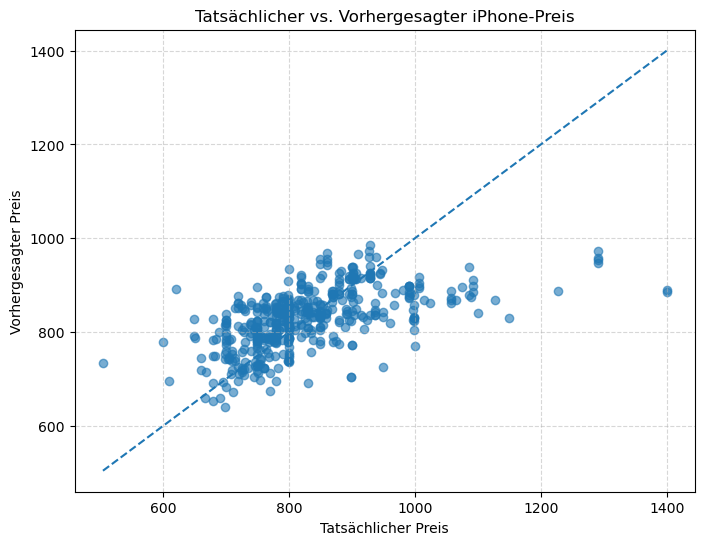

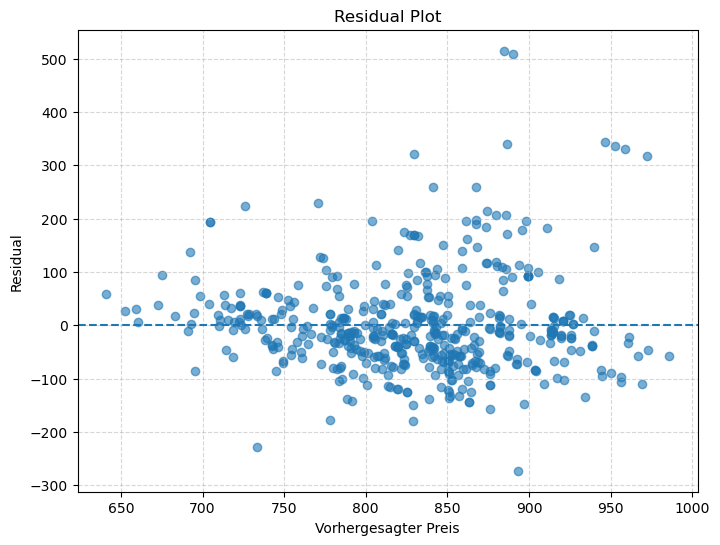

In [13]:
import matplotlib.pyplot as plt

# Create predictions and residuals
regression_df["predicted_price"] = main_model.predict(regression_df)
regression_df["residual"] = regression_df["price"] - regression_df["predicted_price"]


# ============================================================
# Visualisation 1: Actual vs Predicted Price
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    regression_df["price"],
    regression_df["predicted_price"],
    alpha=0.6
)

min_price = min(regression_df["price"].min(), regression_df["predicted_price"].min())
max_price = max(regression_df["price"].max(), regression_df["predicted_price"].max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Tatsächlicher Preis")
plt.ylabel("Vorhergesagter Preis")
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Tatsächlicher vs. Vorhergesagter iPhone-Preis")

plt.show()


# ============================================================
# Visualisation 2: Residual Plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    regression_df["predicted_price"],
    regression_df["residual"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.xlabel("Vorhergesagter Preis")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [15]:
# ============================================================
# TRAIN-TEST SPLIT FOR MAIN MODEL AND RECURRENT SELLER MODEL
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create recurrent seller variable
# ============================================================

model_df["seller_name_clean"] = (
    model_df["Shop/Seller"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model_df.loc[
    model_df["seller_name_clean"].isin(["", "nan", "none", "n/a"]),
    "seller_name_clean"
] = np.nan

model_df["seller_listing_count"] = (
    model_df.groupby("seller_name_clean")["seller_name_clean"]
    .transform("count")
)

model_df["log_seller_listing_count"] = np.log1p(
    model_df["seller_listing_count"]
)


# ============================================================
# 2. Build dataframe for main model
# ============================================================

regression_df_main = model_df[
    [
        "price",
        "Zustand_clean",
        "Farbe_clean",
        "Seller_Type_clean",
        "country_group",
        "Verkaufsart_clean",
        "seller_rating_filled",
        "seller_rating_missing",
        "log_seller_total_sales"
    ]
].copy()

regression_df_main = regression_df_main.dropna()

print("Main model observations:", regression_df_main.shape[0])


# ============================================================
# 3. Build dataframe for recurrent seller model
# ============================================================

regression_df_recurrent = model_df[
    [
        "price",
        "Zustand_clean",
        "Farbe_clean",
        "Seller_Type_clean",
        "country_group",
        "Verkaufsart_clean",
        "seller_rating_filled",
        "seller_rating_missing",
        "log_seller_total_sales",
        "log_seller_listing_count"
    ]
].copy()

regression_df_recurrent = regression_df_recurrent.dropna()

print("Recurrent seller model observations:", regression_df_recurrent.shape[0])


# ============================================================
# 4. Define formulas
# ============================================================

formula_main = """
price ~ C(Zustand_clean, Treatment(reference="neu"))
      + C(Farbe_clean, Treatment(reference="schwarz"))
      + C(Seller_Type_clean, Treatment(reference="privat"))
      + C(country_group, Treatment(reference="deutschland"))
      + C(Verkaufsart_clean, Treatment(reference="sofortkauf"))
      + seller_rating_filled
      + seller_rating_missing
      + log_seller_total_sales
"""

formula_recurrent = """
price ~ C(Zustand_clean, Treatment(reference="neu"))
      + C(Farbe_clean, Treatment(reference="schwarz"))
      + C(Seller_Type_clean, Treatment(reference="privat"))
      + C(country_group, Treatment(reference="deutschland"))
      + C(Verkaufsart_clean, Treatment(reference="sofortkauf"))
      + seller_rating_filled
      + seller_rating_missing
      + log_seller_total_sales
      + log_seller_listing_count
"""


# ============================================================
# 5. Function for train-test evaluation
# ============================================================

def train_test_evaluate(data, formula, model_name):
    # 80% train, 20% test
    train_df, test_df = train_test_split(
        data,
        test_size=0.2,
        random_state=42
    )

    # Fit model only on training data
    model = smf.ols(
        formula=formula,
        data=train_df
    ).fit()

    # Predict train and test
    train_predictions = model.predict(train_df)
    test_predictions = model.predict(test_df)

    # Actual values
    y_train = train_df["price"]
    y_test = test_df["price"]

    # Metrics
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    results = {
        "Model": model_name,
        "Train observations": train_df.shape[0],
        "Test observations": test_df.shape[0],
        "Train R-squared": train_r2,
        "Test R-squared": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    }

    return model, results


# ============================================================
# 6. Run train-test split for both models
# ============================================================

main_train_test_model, main_train_test_results = train_test_evaluate(
    data=regression_df_main,
    formula=formula_main,
    model_name="Main model"
)

recurrent_train_test_model, recurrent_train_test_results = train_test_evaluate(
    data=regression_df_recurrent,
    formula=formula_recurrent,
    model_name="Main model + recurrent sellers"
)


# ============================================================
# 7. Compare results
# ============================================================

train_test_comparison = pd.DataFrame([
    main_train_test_results,
    recurrent_train_test_results
])

train_test_comparison = train_test_comparison.round(4)

print("\n================ TRAIN-TEST COMPARISON ================")
print(train_test_comparison)


# ============================================================
# 8. Optional: print model summaries trained only on training data
# ============================================================

print("\n================ MAIN MODEL TRAINING SUMMARY ================")
print(main_train_test_model.summary())

print("\n================ RECURRENT SELLER MODEL TRAINING SUMMARY ================")
print(recurrent_train_test_model.summary())

Main model observations: 491
Recurrent seller model observations: 490

================ TRAIN-TEST COMPARISON ================
                            Model  Train observations  Test observations  \
0                      Main model                 392                 99   
1  Main model + recurrent sellers                 392                 98   

   Train R-squared  Test R-squared  Train MAE  Test MAE  Train RMSE  Test RMSE  
0           0.3149          0.3496    65.1754   58.4488     91.3936    93.6864  
1           0.3275          0.3225    64.7312   64.4893     90.2489    97.2042  

================ MAIN MODEL TRAINING SUMMARY ================
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     13.36
Date:                T